## 4. MNIST data (\*)

In the whole exercise, we will work with the famous MNIST dataset. Start by installing `tensorflow` to your virtual environment if you haven't already. Import `keras` from tensorflow and load the dataset using `keras.mnist.load_data()`.

&nbsp; a) Check help() on `keras.datasets.mnist.load_data` and read to find out how to unpack the data properly.

&nbsp; b) Check the shapes of X_train, X_test, y_train, y_test. What does each dimension mean?

&nbsp; c) How many images are there in X_train?

&nbsp; d) Check smallest and largest value of a sample image of your choice. What do these numbers in the matrix represent? Plot this image using `plt.imshow()` and set cmap to "gray" to get the correct representation of the grayscale image.

&nbsp; e) Plot 20 sample images.

&nbsp; f) When you checked the shapes of the data you noticed that X_train, X_test are 3D tensors (generalization of a matrix to more dimensions). However KNN classifier in scikit-learn requires a 2D tensor or a matrix. Reshape X_train and X_test to appropriate shapes.

&nbsp; g) Do train|val|test split and scale the data using feature standardization. Check mean and standard deviation of the training and test data.

&nbsp; h) Train the models for a set of $k$-values using the training data and make predictions on validation data. Plot the validation accuracy against different $k$-values. Based on your plot, which $k$ do you choose?

&nbsp; i) Now train the KNN model using the $k$ value you have chosen. Don't waste any training samples, so use all the original 60000 of the X_train for training the KNN model. Predict on the test data.

&nbsp; j) Do a classification report and based on the report, can you figure out which number had highest proportions of false negatives. False negative in this case means that the true label is $i$ but the model predicted not $i$.

&nbsp; k) Plot a confusion matrix, does this confirm your answer in a?

&nbsp; l) Compute the number of misclassifications for each number. Which number had most misclassifications, do you have any suggestions on why this would be the case?

In [65]:
import tensorflow as tf
from tensorflow import keras

# a) Check help() on keras.datasets.mnist.load_data and read to find out how to unpack the data properly.
help(keras.datasets.mnist.load_data())

(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# b) Check the shapes of X_train, X_test, y_train, y_test. What does each dimension mean?
x_train.shape, x_test.shape, y_train.shape, y_test.shape
# 60000 labels/images, each image is a 2d array of shape(28,28) (28x28 pixels)
# 60000 2d arrays within a 3d array, 28 1d arrays within the 2d array, and 28 elements within each 1d array

# c) How many images are there in X_train?
# 60000 images

Help on tuple object:

class tuple(object)
 |  tuple(iterable=(), /)
 |
 |  Built-in immutable sequence.
 |
 |  If no argument is given, the constructor returns an empty tuple.
 |  If iterable is specified the tuple is initialized from iterable's items.
 |
 |  If the argument is a tuple, the return value is the same object.
 |
 |  Built-in subclasses:
 |      asyncgen_hooks
 |      UnraisableHookArgs
 |
 |  Methods defined here:
 |
 |  __add__(self, value, /)
 |      Return self+value.
 |
 |  __contains__(self, key, /)
 |      Return bool(key in self).
 |
 |  __eq__(self, value, /)
 |      Return self==value.
 |
 |  __ge__(self, value, /)
 |      Return self>=value.
 |
 |  __getattribute__(self, name, /)
 |      Return getattr(self, name).
 |
 |  __getitem__(self, key, /)
 |      Return self[key].
 |
 |  __getnewargs__(self, /)
 |
 |  __gt__(self, value, /)
 |      Return self>value.
 |
 |  __hash__(self, /)
 |      Return hash(self).
 |
 |  __iter__(self, /)
 |      Implement iter(sel

((60000, 28, 28), (10000, 28, 28), (60000,), (10000,))

In [66]:
help(keras.datasets.mnist.load_data())

Help on tuple object:

class tuple(object)
 |  tuple(iterable=(), /)
 |
 |  Built-in immutable sequence.
 |
 |  If no argument is given, the constructor returns an empty tuple.
 |  If iterable is specified the tuple is initialized from iterable's items.
 |
 |  If the argument is a tuple, the return value is the same object.
 |
 |  Built-in subclasses:
 |      asyncgen_hooks
 |      UnraisableHookArgs
 |
 |  Methods defined here:
 |
 |  __add__(self, value, /)
 |      Return self+value.
 |
 |  __contains__(self, key, /)
 |      Return bool(key in self).
 |
 |  __eq__(self, value, /)
 |      Return self==value.
 |
 |  __ge__(self, value, /)
 |      Return self>=value.
 |
 |  __getattribute__(self, name, /)
 |      Return getattr(self, name).
 |
 |  __getitem__(self, key, /)
 |      Return self[key].
 |
 |  __getnewargs__(self, /)
 |
 |  __gt__(self, value, /)
 |      Return self>value.
 |
 |  __hash__(self, /)
 |      Return hash(self).
 |
 |  __iter__(self, /)
 |      Implement iter(sel

### d) Check smallest and largest value of a sample image of your choice. What do these numbers in the matrix represent? Plot this image using plt.imshow() and set cmap to "gray" to get the correct representation of the grayscale image.

In [67]:
# each pixel is a digit between 0-255, (grayscale intensity for every pixel)
# max() = 255
# min() = 0
x_train[6].min(), x_train[6].max()

(np.uint8(0), np.uint8(255))

In [68]:
# each label is a digit between 0-9
# max() = 9
# min() = 0
y_train.min(), y_train.max()

(np.uint8(0), np.uint8(9))

In [69]:
x_train[0]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
         18,  18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,   0,
          0,   0],
       [  

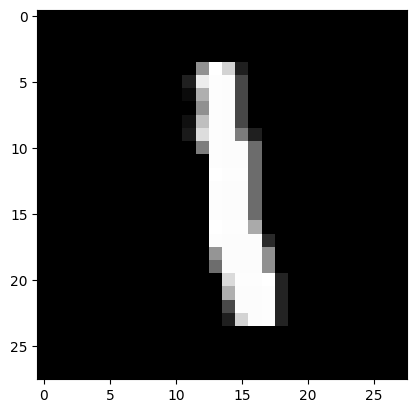

In [70]:
import matplotlib.pyplot as plt

# 0 = black
# 255 = white
# between 0-255 is gray, darker closer to 0, and brighter closer to 255

plt.imshow(x_train[6], cmap="gray")

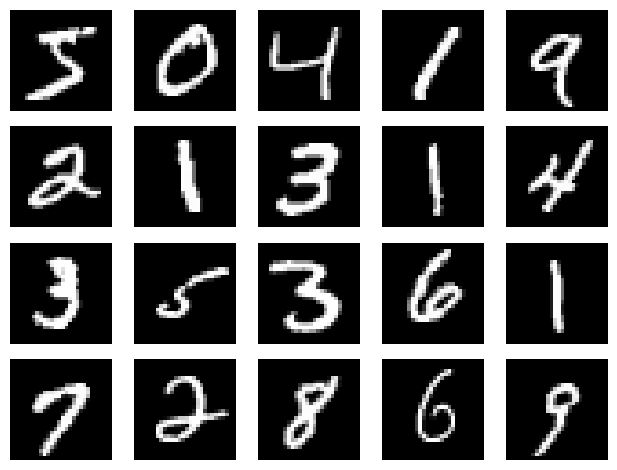

In [71]:
for i in range(0,20):
    plt.subplot(4,5, i+1)
    plt.imshow(x_train[i], cmap="gray")
    plt.axis("off")

plt.tight_layout()
plt.show()

### f) When you checked the shapes of the data you noticed that X_train, X_test are 3D tensors (generalization of a matrix to more dimensions). However KNN classifier in scikit-learn requires a 2D tensor or a matrix. Reshape X_train and X_test to appropriate shapes.

In [72]:
x_train_reshaped = x_train.reshape(x_train.shape[0], -1)
x_test_reshaped = x_test.reshape(x_test.shape[0], -1)

x_train_reshaped.shape, x_test_reshaped.shape

((60000, 784), (10000, 784))

### g) Do train|val|test split and scale the data using feature standardization. Check mean and standard deviation of the training and test data.

In [73]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train_split, y_val = train_test_split(x_train_reshaped, y_train, test_size=0.2, random_state=42)

X_train.shape, X_val.shape

((48000, 784), (12000, 784))

In [74]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(X_train)

scaled_X_train = scaler.transform(X_train)
scaled_X_test = scaler.transform(x_test_reshaped)
scaled_X_val = scaler.transform(X_val)

print(f"{scaled_X_train.mean() = }")
print(f"{scaled_X_train.std() = }\n")

print(f"{scaled_X_test.mean() = }")
print(f"{scaled_X_test.std() = }\n")

print(f"{scaled_X_val.mean() = }")
print(f"{scaled_X_val.std() = }")

scaled_X_train.mean() = np.float64(-1.498423456364837e-18)
scaled_X_train.std() = np.float64(0.9536449944870391)

scaled_X_test.mean() = np.float64(0.0021683162686691876)
scaled_X_test.std() = np.float64(0.9513586500194601)

scaled_X_val.mean() = np.float64(-0.0012910404589343712)
scaled_X_val.std() = np.float64(1.0823403757868508)


### h) Train the models for a set of k-values using the training data and make predictions on validation data. Plot the validation accuracy against different k-values. Based on your plot, which k do you choose?

In [ ]:
from sklearn.metrics import accuracy_score
from sklearn.neighbors import KNeighborsClassifier

error_list = []
for k in range(1,50):
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(scaled_X_train, y_train_split)
    y_pred = model.predict(scaled_X_val)
    error = 1-accuracy_score(y_val, y_pred)
    error_list.append(error)

fig, ax = plt.subplots(1, figsize=(12,5), dpi=150)
plt.plot(range(1,50), error_list, '--o')
ax.set(xlabel="k neighbors", ylabel="error", title="Elbow plot to choose k");

### i) Now train the KNN model using the k value you have chosen. Don't waste any training samples, so use all the original 60000 of the X_train for training the KNN model. Predict on the test data.

In [81]:
final_scaler = StandardScaler()
scaler.fit(x_train_reshaped)

scaled_X_train = scaler.transform(x_train_reshaped)
scaled_X_test = scaler.transform(x_test_reshaped)

In [84]:
scaled_X_train.shape, scaled_X_test.shape

((60000, 784), (10000, 784))

In [85]:
best_k = 3

final_model = KNeighborsClassifier(n_neighbors=best_k)
final_model.fit(scaled_X_train, y_train)

y_pred = final_model.predict(scaled_X_test)

###   j) Do a classification report and based on the report, can you figure out which number had highest proportions of false negatives. False negative in this case means that the true label is i but the model predicted not i.

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# kolla efter klassen med flest FN = recall
print(classification_report(y_test, y_pred))
# 8 has lowest recall(highest proportions of false negatives)

              precision    recall  f1-score   support

           0       0.95      0.99      0.97       980
           1       0.95      0.99      0.97      1135
           2       0.95      0.94      0.94      1032
           3       0.92      0.95      0.94      1010
           4       0.95      0.94      0.95       982
           5       0.93      0.93      0.93       892
           6       0.97      0.97      0.97       958
           7       0.94      0.93      0.93      1028
           8       0.96      0.90      0.93       974
           9       0.93      0.92      0.92      1009

    accuracy                           0.95     10000
   macro avg       0.95      0.94      0.94     10000
weighted avg       0.95      0.95      0.95     10000



### k) Plot a confusion matrix, does this confirm your answer in a?

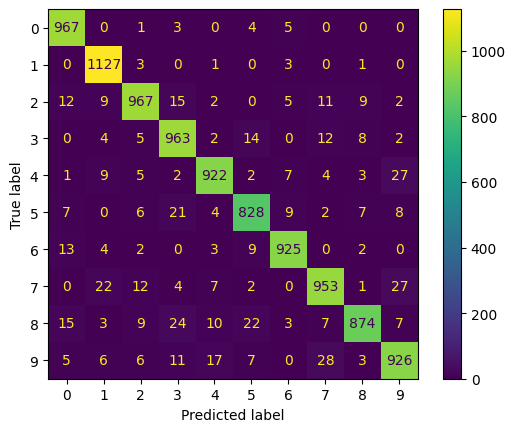

In [ ]:
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm).plot();
# yes

### l) Compute the number of misclassifications for each number. Which number had most misclassifications, do you have any suggestions on why this would be the case?

In [ ]:
misclassifications = [sum(col) - col[i] for i, col in enumerate(cm)]

for i in range(len(misclassifications)):
    print(f"Digit {i}: {misclassifications[i]} misclassifications")

max_value = max(misclassifications)
max_index = misclassifications.index(max_value)
highest = (max_index, max_value)

print(f"\nNumber {highest[0]} had most misclassifications: {highest[1]} errors")

# 8 can easily look like 0, 3, 6 and 9

Digit 0: 13 misclassifications
Digit 1: 8 misclassifications
Digit 2: 65 misclassifications
Digit 3: 47 misclassifications
Digit 4: 60 misclassifications
Digit 5: 64 misclassifications
Digit 6: 33 misclassifications
Digit 7: 75 misclassifications
Digit 8: 100 misclassifications
Digit 9: 83 misclassifications

Number 8 had most misclassifications: 100 errors
